# Optional Lab - 简单神经网络
在这个实验中，我们将使用 Tensorflow 构建一个小型神经网络。
   <center> <img  src="../work/images/C2_W1_CoffeeRoasting.png" width="400" />   <center/>


In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('./deeplearning.mplstyle')
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense
from lab_utils_common import dlc
from lab_coffee_utils import load_coffee_data, plt_roast, plt_roast2, plt_prob, plt_layer, plt_network, plt_output_unit
import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)
%matplotlib widget


## 数据集

In [2]:
X,Y = load_coffee_data();
print(X.shape, Y.shape)

(200, 2) (200, 1)


让我们绘制下面的咖啡烘焙数据。两个特征分别是摄氏温度和以分钟为单位的持续时间。[在家烘焙咖啡](https://www.merchantsofgreencoffee.com/how-to-roast-green-coffee-in-your-oven/)建议持续时间最好保持在 12 到 15 分钟之间，而温度应在 175 到 260 摄氏度之间。当然，随着温度升高，持续时间应该缩短。

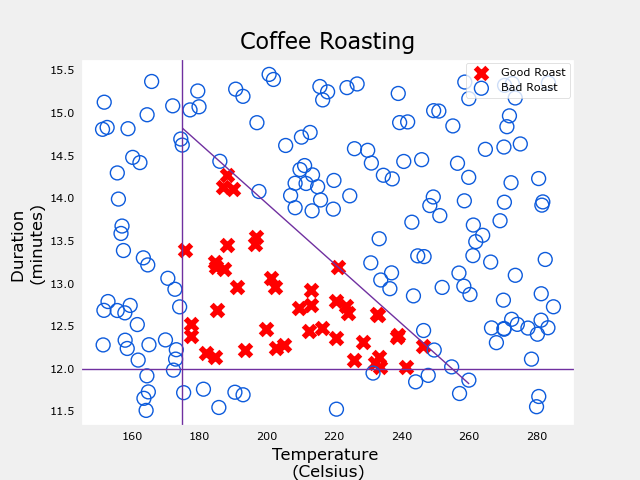

In [3]:
plt_roast(X,Y)

### 数据归一化

如果数据经过归一化处理，将权重拟合到数据（反向传播，将在下周的课程中讲解）的过程会进行得更快。这与你在课程 1 中使用的过程相同，在课程 1 中，数据中的特征都经过归一化处理，以使其具有相似的范围。下面的过程使用了 Keras 的[归一化层](https://keras.io/api/layers/preprocessing_layers/numerical/normalization/)。它有以下步骤：
- 创建一个“归一化层”。请注意，在这里应用时，这不是你的模型中的一层。
- `adapter`数据。这会学习数据集的均值和方差，并在内部保存这些值。
- 归一化数据。
对任何使用已学习模型的未来数据，应用归一化处理是很重要的。

In [4]:
print(f"Temperature Max, Min pre normalization: {np.max(X[:,0]):0.2f}, {np.min(X[:,0]):0.2f}")
print(f"Duration    Max, Min pre normalization: {np.max(X[:,1]):0.2f}, {np.min(X[:,1]):0.2f}")
norm_l = tf.keras.layers.Normalization(axis=-1)
norm_l.adapt(X)  # learns mean, variance
Xn = norm_l(X)
print(f"Temperature Max, Min post normalization: {np.max(Xn[:,0]):0.2f}, {np.min(Xn[:,0]):0.2f}")
print(f"Duration    Max, Min post normalization: {np.max(Xn[:,1]):0.2f}, {np.min(Xn[:,1]):0.2f}")

Temperature Max, Min pre normalization: 284.99, 151.32
Duration    Max, Min pre normalization: 15.45, 11.51
Temperature Max, Min post normalization: 1.66, -1.69
Duration    Max, Min post normalization: 1.79, -1.70


对我们的数据进行平铺/复制以增加训练集的大小并减少训练轮数。

In [5]:
Xt = np.tile(Xn,(1000,1))
Yt= np.tile(Y,(1000,1))
print(Xt.shape, Yt.shape)

(200000, 2) (200000, 1)


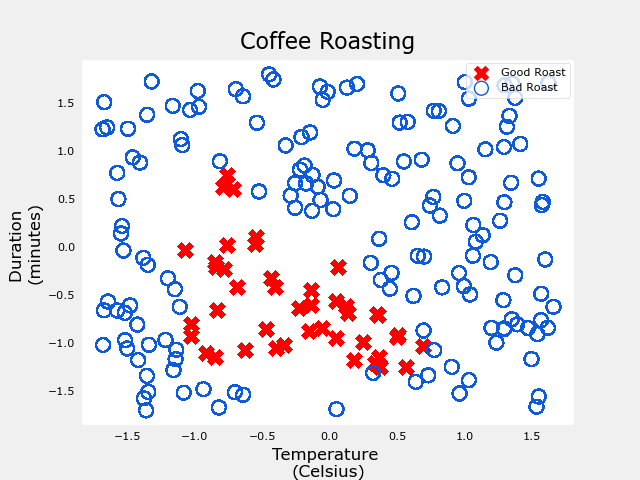

In [6]:
plt_roast2(Xt,Yt)

## Tensorflow Model

### Model
   <center> <img  src="../work/images/C2_W1_RoastingNetwork.PNG" width="200" />   <center/>  
让我们构建讲座中描述的“咖啡烘焙网络”。如下面所示，有两层具有 sigmoid 激活函数：

In [7]:
tf.random.set_seed(1234)  # applied to achieve consistent results
model = Sequential(
    [
        tf.keras.Input(shape=(2,)),
        Dense(3, activation='sigmoid', name = 'layer1'),
        Dense(1, activation='sigmoid', name = 'layer2')
     ]
)

>**注意事项 1**：`tf.keras.Input(shape=(2,))`指定了输入的预期形状。这使得 TensorFlow 能够在此处确定权重和偏差参数的size。在探索 TensorFlow 模型时这很有用。在实际应用中，此语句可以省略，并且当在`model.fit`语句中指定输入数据时，TensorFlow 将确定网络参数的size。

>**注意事项 2**：在最后一层中包含 sigmoid 激活函数不被认为是最佳实践。相反，它将在损失中被考虑，这可以提高数值稳定性。这将在后面的实验中更详细地描述。`model.summary()`提供了网络的描述：

`model.summary()`提供了网络的描述：

In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer1 (Dense)                  │ (None, 3)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer2 (Dense)                  │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13 (52.00 B)

 Trainable params: 13 (52.00 B)

 Non-trainable params: 0 (0.00 B)

摘要中显示的参数计数对应于如下所示的权重和偏差数组中的元素数量。

In [9]:
L1_num_params = 2 * 3 + 3   # W1 parameters  + b1 parameters
L2_num_params = 3 * 1 + 1   # W2 parameters  + b2 parameters
print("L1 params = ", L1_num_params, ", L2 params = ", L2_num_params  )

L1 params =  9 , L2 params =  4


让我们检查 Tensorflow 实例化的权重和偏差。权重$W$的size应为（输入中的特征数量，层中的单元数量），而偏差$b$的size应与层中的单元数量匹配：
- 在具有 3 个单元的第一层中，我们期望$W$的size为(2,3)，并且$b$应该有 3 个元素。
- 在具有 1 个单元的第二层中，我们期望$W$的size为(3,1)，并且$b$应该有 1 个元素。

以下陈述将在第 2 周进行详细描述。目前你只需要知道：
- `model.compile`语句定义了损失函数并指定了编译优化。
- `model.fit`语句运行梯度下降并使权重适应数据。

In [10]:
model.compile(
    loss = tf.keras.losses.BinaryCrossentropy(),
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.01),
)

model.fit(
    Xt,Yt,            
    epochs=10,
)

Epoch 1/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 2s 309us/step - loss: 0.2838
Epoch 2/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 2s 324us/step - loss: 0.1394
Epoch 3/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 2s 318us/step - loss: 0.1350
Epoch 4/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 2s 305us/step - loss: 0.1331
Epoch 5/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 2s 316us/step - loss: 0.1320
Epoch 6/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 2s 307us/step - loss: 0.1312
Epoch 7/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 2s 332us/step - loss: 0.1306
Epoch 8/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 2s 327us/step - loss: 0.1301
Epoch 9/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 2s 324us/step - loss: 0.1297
Epoch 10/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 2s 322us/step - loss: 0.1294


#### 更新权重
拟合后，权重已更新：

In [11]:
W1, b1 = model.get_layer("layer1").get_weights()
W2, b2 = model.get_layer("layer2").get_weights()
print("W1:\n", W1, "\nb1:", b1)
print("W2:\n", W2, "\nb2:", b2)

W1:
 [[ -7.3    6.22  10.18]
 [ -2.23 -17.35   7.3 ]] 
b1: [-11.32  20.22  -1.48]
W2:
 [[-19.74]
 [  7.71]
 [-22.84]] 
b2: [-5.48]


接下来，我们将加载之前训练运行中保存的一些权重。这样做是为了让这个笔记本在TensorFlow随时间变化时仍保持稳健。不同的训练运行可能会产生略有不同的结果，下面的讨论适用于特定的解决方案。你可以自由地在注释掉此单元格的情况下重新运行笔记本，以查看差异。 

In [12]:
W1 = np.array([
    [-8.94,  0.29, 12.89],
    [-0.17, -7.34, 10.79]] )
b1 = np.array([-9.87, -9.28,  1.01])
W2 = np.array([
    [-31.38],
    [-27.86],
    [-32.79]])
b2 = np.array([15.54])
model.get_layer("layer1").set_weights([W1,b1])
model.get_layer("layer2").set_weights([W2,b2])

### 预测结果
<img align="left" src="../work/images/C2_W1_RoastingDecision.PNG"     style=" width:380px; padding: 10px 20px; " >

一旦你有了一个训练好的模型，就可以用它进行预测。回想一下，我们模型的输出是一个概率。在这种情况下，是烤得好的概率。为了做出决策，必须将这个概率应用于一个阈值。在这种情况下，我们将使用0.5。

我们从创建输入数据开始。模型需要一个或多个样本，这些样本位于矩阵的行中。在这种情况下，我们有两个特征，因此矩阵将是 (m, 2)，其中 m 是样本的数量。请记住，我们已经对输入特征进行了归一化处理，所以我们也必须对测试数据进行归一化。要进行预测，你需应用 `predict` 方法。

In [13]:
X_test = np.array([
    [200,13.9],  # postive example
    [200,17]])   # negative example
X_testn = norm_l(X_test)
layer_1 = model.get_layer("layer1")
a1 = layer_1(X_testn)
print(a1)
layer_2 = model.get_layer("layer2")
a2 = layer_2(a1)
print(a2)
predictions = model.predict(X_testn)
print("predictions = \n", predictions)

tf.Tensor(
[[3.13e-03 3.85e-06 3.72e-01]
 [1.96e-03 6.73e-15 1.00e+00]], shape=(2, 3), dtype=float32)
tf.Tensor(
[[9.63e-01]
 [3.03e-08]], shape=(2, 1), dtype=float32)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
predictions = 
 [[9.63e-01]
 [3.03e-08]]


#### 轮次与批次
在上述`compile`语句中，`epochs`（轮次）的数量被设置为10。这表明在训练过程中，整个数据集应被应用10次。在训练期间，你会看到描述训练进度的输出，如下所示：
```
Epoch 1/10
6250/6250 [==============================] - 6s 910us/step - loss: 0.1782
```
第一行“Epoch 1/10”描述了模型当前正在运行的轮次。为提高效率，训练数据集被划分为“批次”。TensorFlow中批次的默认大小为32。我们扩展后的数据集有200000个样本，即6250个批次。第二行的表示“6250/6250 [====”描述了已执行的批次。 

为了将概率转化为决策，我们应用一个阈值：

In [14]:
yhat = np.zeros_like(predictions)
print(f"yhat = \n{yhat}")

for i in range(len(predictions)):
    if predictions[i] >= 0.5:
        yhat[i] = 1
    else:
        yhat[i] = 0
print(f"decisions = \n{yhat}")

yhat = 
[[0.]
 [0.]]
decisions = 
[[1.]
 [0.]]


这可以更简洁地完成：

In [15]:
yhat = (predictions >= 0.5).astype(int)
print(f"decisions = \n{yhat}")

decisions = 
[[1]
 [0]]


## 层函数
让我们研究这些神经元的函数，以确定它们在咖啡烘焙决策中的作用。我们将绘制每个神经元在所有输入值（时长、温度）下的输出。每个神经元都是一个逻辑函数，其输出范围可以从0到1。图中的阴影表示输出值。
> 注意：在实验中，我们通常从0开始对事物进行编号，而在讲座中可能从1开始。 

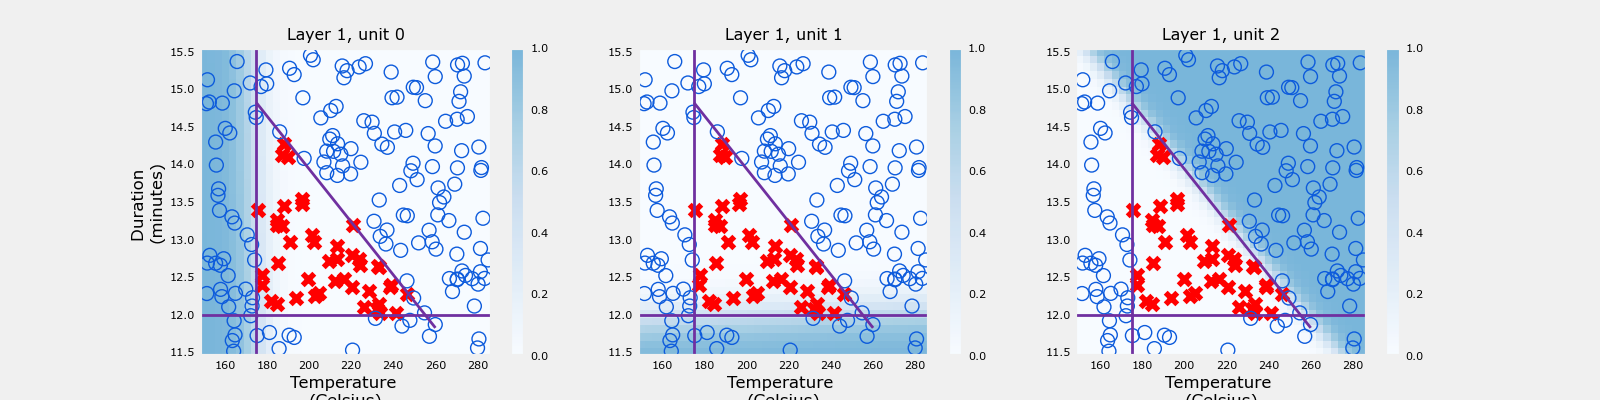

In [16]:
plt_layer(X,Y.reshape(-1,),W1,b1,norm_l)

阴影部分表明，每个单元负责不同的“烘焙不佳”区域。当温度过低时，神经元0的值较大。当持续时间过短时，神经元1的值较大，而当时间/温度组合不佳时，神经元2的值较大。

值得注意的是，该网络通过梯度下降过程自行学习了这些函数。它们与人们在做出相同决策时可能选择的函数非常相似。 

最后一层的函数图要可视化起来有点难度。它的输入是第一层的输出。我们知道第一层使用的是 sigmoid 函数，所以其输出范围在0到1之间。我们可以创建一个三维图，计算出三个输入所有可能组合的输出。如下所示。在上方，高输出值对应“烘焙不佳”区域。在下方，最大输出出现在三个输入值都较小的区域，对应“烘焙良好”区域。 

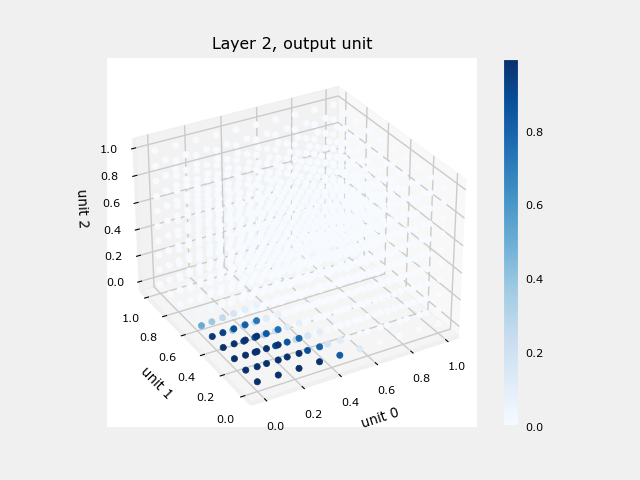

In [17]:
plt_output_unit(W2,b2)

最后一张图展示了整个网络的运行情况。  
左边的图是最后一层的原始输出，用蓝色阴影表示。这叠加在由X和O表示的训练数据上。  
右边的图是经过决策阈值处理后网络的输出。这里的X和O对应于网络做出的决策。  
接下来的内容运行需要一些时间。 

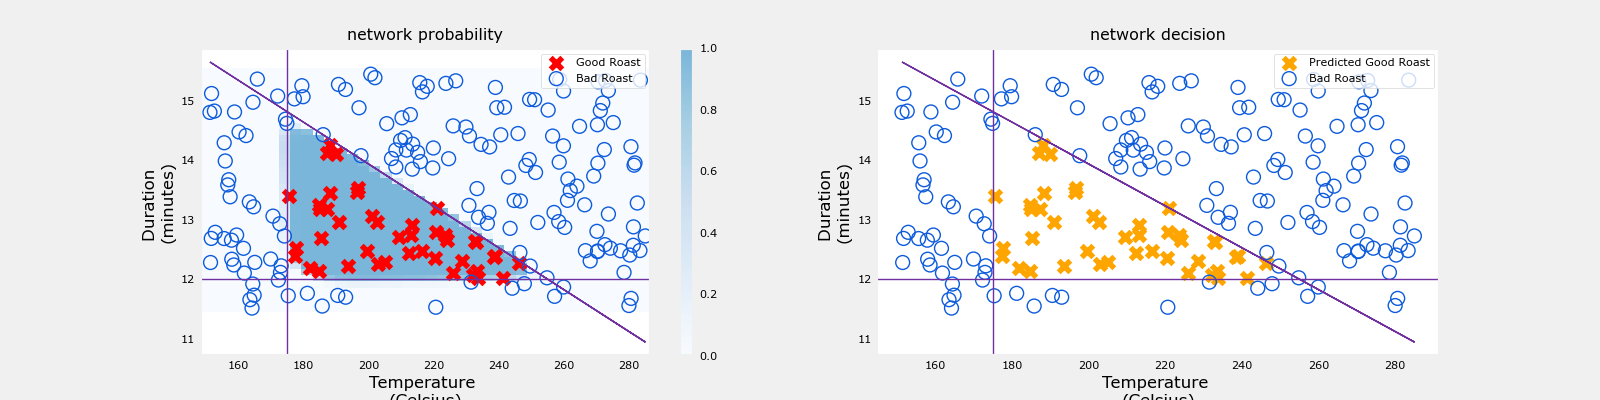

In [18]:
netf= lambda x : model.predict(norm_l(x), verbose=0)
plt_network(X,Y,netf)

## 恭喜！
你已经在TensorFlow中构建了一个小型神经网络。

该网络通过将决策分配到多个单元之间，展示了神经网络处理复杂决策的能力。